# Problem 1: Real GDP across US states


In [1]:
import os
import time
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from states import STATES, REGION   # state codes + region mapping

# API key - only needed if we don't already have the data cached (see download_panel below)
FRED_API_KEY = os.environ.get("FRED_API_KEY", "")
FRED_URL = "https://api.stlouisfed.org/fred/series/observations"

# cache the downloads locally so we don't have to re-hit the API every time we re-run this
CACHE_DIR = "data"
os.makedirs(CACHE_DIR, exist_ok=True)


## 1.1 Question 1

### 1. Download the data

For each state we need two FRED series: `XXRGSP` (real GDP) and `XXPOP` (population).
We wrote a helper function, `fetch_series`, that calls the FRED `series/observations`
endpoint for one series and returns it as a `pandas.Series` indexed by year. We loop
over `STATES` twice, once for RGSP and once for POP, to build two data frames with
years as rows and states as columns, and cache the raw downloads to
`data/RGSP_raw.csv` and `data/POP_raw.csv` so we don't have to re-download everything
every time we rerun the notebook.


In [2]:
def fetch_series(series_id, api_key=FRED_API_KEY):
    ''' download one FRED series and return it as a pandas Series indexed by year '''

    params = {"series_id": series_id, "api_key": api_key, "file_type": "json"}
    r = requests.get(FRED_URL, params=params, timeout=30)
    r.raise_for_status()

    obs = r.json()["observations"]
    df = pd.DataFrame(obs)[["date", "value"]]
    df["year"] = pd.to_datetime(df["date"]).dt.year
    df["value"] = pd.to_numeric(df["value"], errors="coerce")  # FRED uses "." for missing

    return df.set_index("year")["value"]


def download_panel(suffix, cache_name):
    ''' download <state><suffix> for all 50 states into one years x states data frame '''

    cache_path = os.path.join(CACHE_DIR, cache_name)
    if os.path.exists(cache_path):
        return pd.read_csv(cache_path, index_col=0)

    # only reach this point (and need the API key) if we don't already have a cached copy
    assert FRED_API_KEY, "No FRED API key found, and no cached data at " + cache_path

    data = {}
    for state in STATES:
        data[state] = fetch_series(state + suffix)
        time.sleep(0.05)  # be a little polite to the API

    panel = pd.DataFrame(data)
    panel.index.name = "year"
    panel.to_csv(cache_path)

    return panel


# build the RGSP and POP panels, one column per state, using the cache if we have it already
RGSP = download_panel("RGSP", "RGSP_raw.csv")   # millions of chained 2017 dollars
POP  = download_panel("POP",  "POP_raw.csv")    # thousands of persons

print("RGSP:", RGSP.shape, "years", RGSP.index.min(), "-", RGSP.index.max())
print("POP: ", POP.shape,  "years", POP.index.min(),  "-", POP.index.max())


RGSP: (29, 50) years 1997 - 2025
POP:  (126, 50) years 1900 - 2025


### 2. Align years and drop states with missing data

`RGSP` and `POP` don't cover exactly the same years. Population data usually goes
further back, and the most recent year can be missing from one of them. We first
keep only the years that appear in both, then drop any state that still has a
missing value somewhere in that window.


In [3]:
# restrict both panels to the years they have in common
common_years = RGSP.index.intersection(POP.index)
RGSP_c = RGSP.loc[common_years]
POP_c = POP.loc[common_years]

# a state is only kept if it has a complete record (both series) over that window
states_kept = [s for s in STATES if RGSP_c[s].notna().all() and POP_c[s].notna().all()]
dropped = [s for s in STATES if s not in states_kept]

RGSP_c = RGSP_c[states_kept]
POP_c = POP_c[states_kept]

print(f"{len(common_years)} years ({common_years.min()}-{common_years.max()}), {len(states_kept)} states kept")
if dropped:
    print("states dropped for missing data:", dropped)


29 years (1997-2025), 50 states kept


We are left with 29 years (1997 to 2025) and all 50 states. No state had to be
dropped for missing data in this window.


### 3. Real GDP per person

`RGSP` is in **millions** of dollars and `POP` is in **thousands** of persons, so

$$y_{i,t} = \frac{RGSP_{i,t}\times 10^6}{POP_{i,t}\times 10^3} = \frac{RGSP_{i,t}}{POP_{i,t}}\times 1000$$

gives real GDP per person in (chained 2017) dollars.


In [4]:
y = RGSP_c / POP_c * 1000   # dollars per person

t_first, t_last = y.index.min(), y.index.max()
print("t_first =", t_first, " t_last =", t_last)
y.head()


t_first = 1997  t_last = 2025


,AL,AK,AZ,AR,CA,CO,CT,DE,FL,GA,...,SD,TN,TX,UT,VT,VA,WA,WV,WI,WY
year,,,,,,,,,,,,,,,,,,,,,
1997,35807.856017,67457.123805,39605.821967,34540.435110,44733.982939,48684.486108,63014.935839,69748.742898,41134.250699,46911.500176,...,37102.024341,42174.514399,44434.405916,41775.745777,36306.218308,47526.867411,50234.997381,33247.961542,42878.542989,50533.611371
1998,36863.947606,65447.615023,42314.201621,35420.860909,47077.134837,52015.826788,64858.950003,75916.652555,42529.012498,49460.461189,...,39371.282272,44354.433604,46674.180385,43470.604533,37702.830612,49921.971948,52711.999932,34070.822349,44443.046546,51671.614120
1999,38109.166834,64218.079096,44847.009375,37139.571517,49945.163875,54495.451702,66684.318338,80773.895942,43950.848785,51932.811521,...,40972.511127,45309.731770,47756.958006,44701.469972,39683.531512,51854.555973,56063.474824,35248.609795,46096.274488,53933.886848
2000,37890.553669,61194.847467,43547.244441,35656.771403,52498.582072,55175.331373,68549.087470,80609.074828,43236.432557,50771.619813,...,42502.024227,44011.670280,47263.240816,43951.174915,40754.374051,52480.115939,55131.873516,35065.779534,46254.567595,53842.201092
2001,37704.140491,63142.679505,43782.422868,35491.800142,51757.417416,54827.668563,68846.332550,82600.078673,43690.131776,50463.135060,...,42741.552458,43526.444806,47867.499715,43895.275899,41948.440356,53685.088358,53103.134426,35304.174732,46781.860367,57288.383668


### 4. Highest and lowest $y_{i,t}$

For $t_{first}$ and $t_{last}$ we report the state with the highest and the lowest
$y_{i,t}$, the ratio between them, and the average across states.


In [5]:
def report_extremes(t):
    ''' print the highest/lowest state, their ratio, and the average, for one year '''

    row = y.loc[t]
    s_max, v_max = row.idxmax(), row.max()
    s_min, v_min = row.idxmin(), row.min()
    avg = row.mean()

    print(f"year {t}:")
    print(f"  highest: {s_max}  ${v_max:,.0f}")
    print(f"  lowest:  {s_min}  ${v_min:,.0f}")
    print(f"  ratio highest/lowest: {v_max/v_min:.2f}")
    print(f"  average across states: ${avg:,.0f}")
    print()

# report both endpoints of the sample
report_extremes(t_first)
report_extremes(t_last)


year 1997:
  highest: DE  $69,749
  lowest:  ID  $32,063
  ratio highest/lowest: 2.18
  average across states: $44,593

year 2025:
  highest: NY  $94,702
  lowest:  MS  $42,434
  ratio highest/lowest: 2.23
  average across states: $64,674



In 1997 Delaware has the highest $y_{i,t}$ (\$69,749) and Idaho the lowest
(\$32,063), a ratio of 2.18. By 2025 New York is highest (\$94,702) and Mississippi
lowest (\$42,434), a ratio of 2.23. So the gap between the richest and poorest state
is, if anything, slightly wider by the end of the sample, even though the average
across states has risen from \$44,593 to \$64,674.


### 5. Figure

Two panels: (i) $y_{i,t}$ against $t$ for a handful of states plus the average
across all states, and (ii) $y_{i,t}$ divided by the average across states in the
same year, for *all* states (so every state's line hovers around 1).


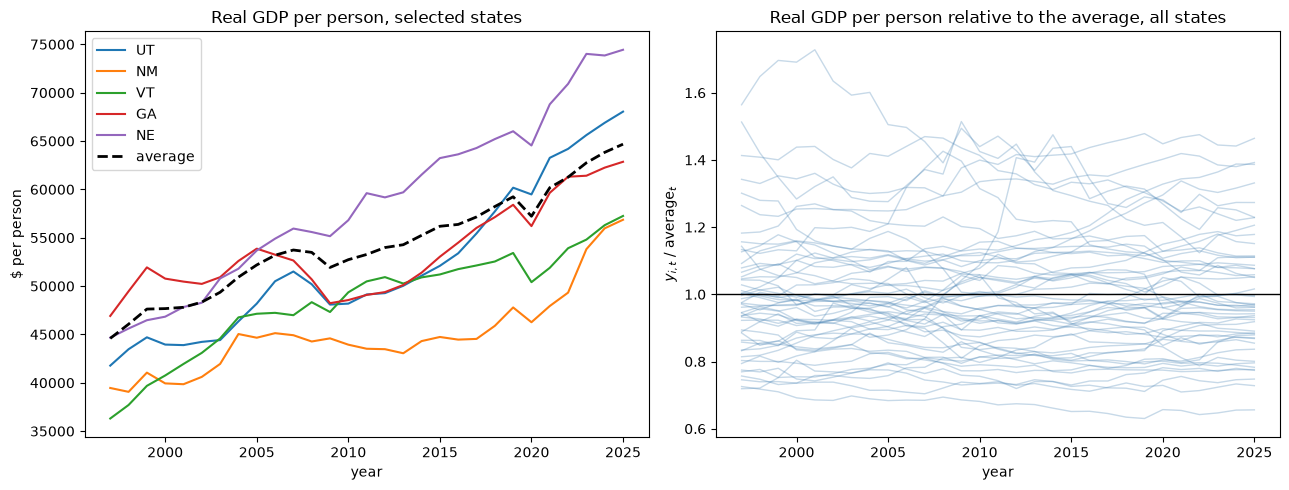

In [6]:
# states to highlight in panel i)
candidates = ["UT", "NM", "VT", "GA", "NE"]
chosen_states = [s for s in candidates if s in y.columns][:5]

avg_y = y.mean(axis=1)
rel_y = y.div(avg_y, axis=0)   # y_it / average_t, for all states -- reused in Question 4 below

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# panel i): levels for a few states plus the cross-state average
for s in chosen_states:
    axes[0].plot(y.index, y[s], label=s)
axes[0].plot(y.index, avg_y, color="black", linewidth=2, linestyle="--", label="average")
axes[0].set_title("Real GDP per person, selected states")
axes[0].set_xlabel("year")
axes[0].set_ylabel("$ per person")
axes[0].legend()

# panel ii): every state relative to that year's average, so lines cluster around 1
for s in y.columns:
    axes[1].plot(rel_y.index, rel_y[s], color="steelblue", alpha=0.3, linewidth=1)
axes[1].axhline(1.0, color="black", linewidth=1)
axes[1].set_title("Real GDP per person relative to the average, all states")
axes[1].set_xlabel("year")
axes[1].set_ylabel(r"$y_{i,t}$ / average$_t$")

fig.tight_layout()
fig.savefig("problem1_fig1.png", dpi=150)
plt.show()


## 1.2 Question 2

For each year we compute the standard deviation across states of $\log y_{i,t}$,
and plot it against the year. This is a standard measure of cross-sectional
dispersion (sigma-convergence): if it trends down, states are becoming more
similar in GDP per person over time.


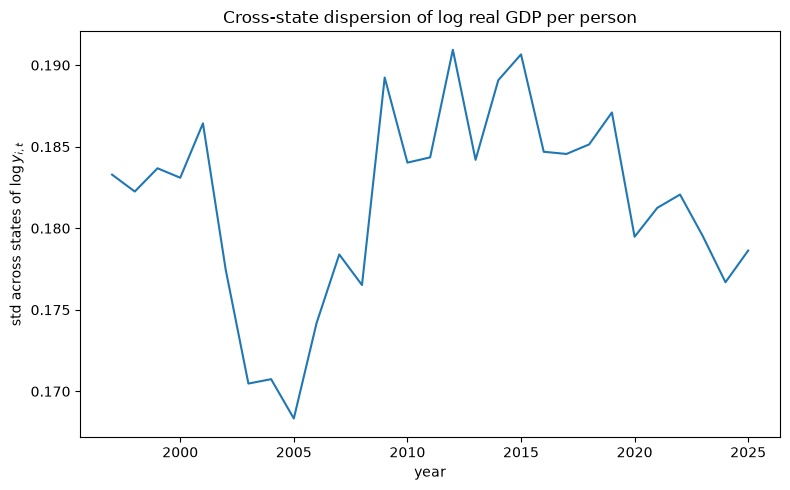

std in 1997: 0.1833
std in 2025:  0.1786
highest: 2012  (0.1909)
lowest:  2005  (0.1683)


In [7]:
log_y = np.log(y)
std_by_year = log_y.std(axis=1)   # cross-state std of log y, one number per year

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(std_by_year.index, std_by_year.values)
ax.set_xlabel("year")
ax.set_ylabel(r"std across states of $\log y_{i,t}$")
ax.set_title("Cross-state dispersion of log real GDP per person")
fig.tight_layout()
fig.savefig("problem1_fig2.png", dpi=150)
plt.show()

print(f"std in {t_first}: {std_by_year.loc[t_first]:.4f}")
print(f"std in {t_last}:  {std_by_year.loc[t_last]:.4f}")
print(f"highest: {std_by_year.idxmax()}  ({std_by_year.max():.4f})")
print(f"lowest:  {std_by_year.idxmin()}  ({std_by_year.min():.4f})")


**Describe what the figure shows. Is there a clear trend?**

There is no single clear trend over the full period. The series moves in swings
tied to the business cycle rather than drifting steadily in one direction.
Dispersion falls to its lowest point in 2005 (0.168), then rises sharply and stays
elevated and volatile through the 2010s (roughly 0.184-0.191, peaking in 2012),
consistent with the 2008 financial crisis hitting states unevenly. It falls again
around 2019-2020 and drifts down toward 2024, before ticking back up slightly in
2025. Overall, the std falls only slightly from 1997 (0.183) to 2025 (0.179), but
that small net change hides a much bigger swing in between.


## 1.3 Question 3

For each state the average annual growth rate between $t_{first}$ and $t_{last}$ is

$$g_i = \frac{\log y_{i,t_{last}} - \log y_{i,t_{first}}}{t_{last}-t_{first}}$$

We regress $g_i$ on $\log y_{i,t_{first}}$ with `np.polyfit`; a negative slope $b$
means poorer states (low initial $y$) grew faster, which is absolute convergence.


In [8]:
T = t_last - t_first

g = (log_y.loc[t_last] - log_y.loc[t_first]) / T   # one number per state
x0 = log_y.loc[t_first]                              # log y_i,t_first, one number per state

b, a = np.polyfit(x0, g, 1)     # g = a + b*x0  (np.polyfit returns [slope, intercept])
corr = np.corrcoef(x0, g)[0, 1]

print(f"a = {a:.5f}, b = {b:.5f}")
print(f"correlation(g_i, log y_i,t_first) = {corr:.3f}")


a = 0.11809, b = -0.00980
correlation(g_i, log y_i,t_first) = -0.389


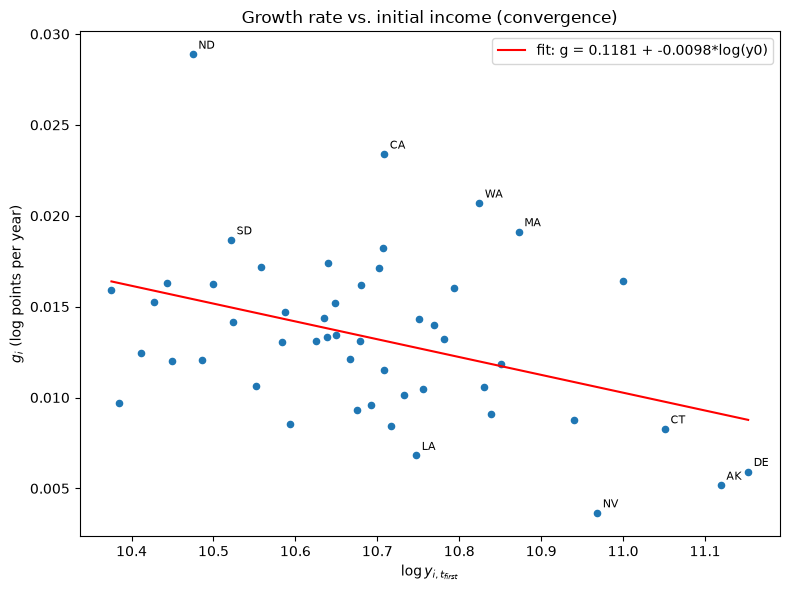

highest g_i:
 ND    0.028886
CA    0.023389
WA    0.020697
MA    0.019120
SD    0.018669
dtype: float64

lowest g_i:
 NV    0.003652
AK    0.005174
DE    0.005929
LA    0.006811
CT    0.008271
dtype: float64


In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(x0, g, s=20)

xs = np.linspace(x0.min(), x0.max(), 100)
ax.plot(xs, a + b*xs, color="red", label=f"fit: g = {a:.4f} + {b:.4f}*log(y0)")

# label the five states with the highest and the five with the lowest g_i
top5 = g.sort_values(ascending=False).head(5)
bot5 = g.sort_values(ascending=True).head(5)
for s in pd.concat([top5, bot5]).index:
    ax.annotate(s, (x0[s], g[s]), textcoords="offset points", xytext=(4, 4), fontsize=8)

ax.set_xlabel(r"$\log y_{i,t_{first}}$")
ax.set_ylabel(r"$g_i$ (log points per year)")
ax.set_title("Growth rate vs. initial income (convergence)")
ax.legend()
fig.tight_layout()
fig.savefig("problem1_fig3.png", dpi=150)
plt.show()

print("highest g_i:\n", top5)
print("\nlowest g_i:\n", bot5)


In [10]:
lam = -np.log(1 + b*T) / T   # annual speed of convergence
h = np.log(2) / lam           # half-life

print(f"lambda = {lam:.5f} (per year)")
print(f"h      = {h:.2f} years")


lambda = 0.01146 (per year)
h      = 60.49 years


**Describe the figure. How closely do the points follow the fitted line?**

The slope is negative ($b = -0.0098$) and the correlation is a moderate $-0.389$,
so there is a real but noisy convergence pattern: states that started poorer in
1997 tended to grow faster, but initial income only explains part of the variation
in growth rates. The implied speed of convergence is $\lambda \approx 1.1\%$ per
year, with a half-life of about 60 years, much slower than the classic ~2%/year
rule of thumb from the convergence literature, which fits a longer historical
sample than ours.

The scatter is fairly spread out around the line rather than tightly clustered.
Some of the fastest-growing states (ND, CA, WA, MA, SD) sit well above the fitted
line, so their growth is not explained by having a low starting income. ND in
particular grew fast from a middling starting point, most likely on the back of
its shale oil boom, while CA, WA and MA started from *above*-average income and
still grew quickly, driven by tech and finance. On the other side, DE and CT sit
below the line: both started rich and grew slowly, which is what the convergence
story predicts. But NV, AK and LA also sit below the line despite not being
especially rich to begin with, so their slow growth (housing bust, oil prices,
hurricane damage) is a story about specific shocks, not just initial income.


## 1.4 Question 4

Using `REGION` from `states.py`, we compute, for every year and every region, the
average within that region of $y_{i,t}/\text{average}_t$ (the same relative measure
as panel ii of Question 1), via a `groupby`.


In [11]:
# map each kept state to its Census region, and count how many states are in each
region_map = {s: REGION[s] for s in states_kept}
n_per_region = pd.Series(region_map).value_counts()
print("states per region:\n", n_per_region)

# reshape rel_y (years x states) to long format, tag each state with its region,
# then average within region and year
rel_long = rel_y.stack().rename("rel").reset_index()
rel_long.columns = ["year", "state", "rel"]
rel_long["region"] = rel_long["state"].map(region_map)

region_avg = rel_long.groupby(["year", "region"])["rel"].mean().unstack()
region_avg.head()


states per region:
 South        16
West         13
Midwest      12
Northeast     9
Name: count, dtype: int64


region,Midwest,Northeast,South,West
year,,,,
1997,0.968332,1.087340,0.951318,1.028682
1998,0.968472,1.087564,0.957887,1.020313
1999,0.962879,1.091557,0.958916,1.021444
2000,0.976595,1.110827,0.943301,1.014661
2001,0.969318,1.119563,0.948591,1.008820


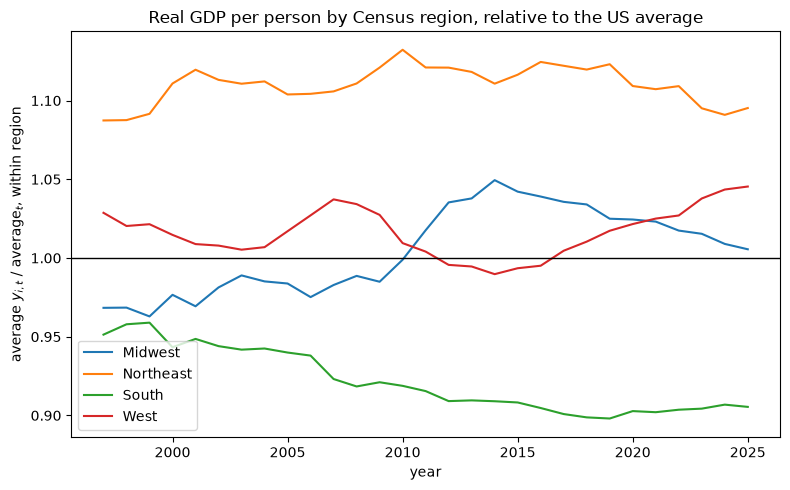

In [12]:
# plot the four regional relative-income series over time
fig, ax = plt.subplots(figsize=(8, 5))
for reg in region_avg.columns:
    ax.plot(region_avg.index, region_avg[reg], label=reg)
ax.axhline(1.0, color="black", linewidth=1)
ax.set_xlabel("year")
ax.set_ylabel(r"average $y_{i,t}$ / average$_t$, within region")
ax.set_title("Real GDP per person by Census region, relative to the US average")
ax.legend()
fig.tight_layout()
fig.savefig("problem1_fig4.png", dpi=150)
plt.show()


In [13]:
# compare each region's relative position in t_first vs. t_last, sorted by size of the move
summary = pd.DataFrame({
    "t_first": region_avg.loc[t_first],
    "t_last": region_avg.loc[t_last],
})
summary["change"] = summary["t_last"] - summary["t_first"]
summary = summary.sort_values("change", key=lambda s: s.abs(), ascending=False)
summary


,t_first,t_last,change
region,,,
South,0.951318,0.905418,-0.045900
Midwest,0.968332,1.005527,0.037194
West,1.028682,1.045378,0.016696
Northeast,1.087340,1.095232,0.007892


**Which region moves the most, and in which direction?**

The South moves the most, and it moves in the "wrong" direction: it falls from
0.951 to 0.905 times the national average, i.e. it becomes relatively poorer even
though the country as a whole is converging in other respects. The Midwest moves
almost as much but the other way, rising from 0.968 to 1.006. It goes from
below-average to essentially at the national average. The West and Northeast barely
move (+0.017 and +0.008 respectively) and stay roughly where they started, with the
Northeast consistently the richest region throughout. So regional convergence is
not uniform: it is really a Midwest-catches-up, South-falls-behind story, not every
region drifting toward the middle.
